In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [3]:
csv_path = "/kaggle/input/datasets/anshkarki/cyber-dataset-neural-nexus/combined_noisy.csv"

In [5]:
print("Dataset")
df = pd.read_csv(csv_path, low_memory=False)

Dataset


In [6]:
df.columns = df.columns.str.strip()

In [7]:
LABEL_COL = "Label"
feature_cols = [c for c in df.columns if c not in
                ["Flow ID", "Src IP", "Dst IP", "Timestamp", LABEL_COL]]

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Features: {len(feature_cols)}")
print(f"Labels  : {df[LABEL_COL].nunique()} unique classes\n")



Shape  : 1,775,435 rows × 84 columns
Features: 79
Labels  : 1588 unique classes



In [8]:
print("=" * 60)
print("Basic Info")
print("=" * 60)
print(df.dtypes.value_counts().rename("count").to_string())
print("\nFirst 5 rows:")
print(df.head())
print("\nDescriptive statistics:")
print(df[feature_cols].describe().T.to_string())


Basic Info
float64    64
object     14
int64       6

First 5 rows:
                                   Flow ID         Src IP  Src Port  \
0  192.168.10.50-192.168.10.3-56108-3268-6  192.168.10.50   56108.0   
1   192.168.10.50-192.168.10.3-42144-389-6  192.168.10.50   42144.0   
2                    8.6.0.1-8.0.6.4-0-0-0        8.6.0.1       0.0   
3   192.168.10.25-224.0.0.251-5353-5353-17  192.168.10.25    5353.0   
4   192.168.10.25-17.253.14.125-123-123-17  192.168.10.25     123.0   

          Dst IP Dst Port Protocol                      Timestamp  \
0   192.168.10.3     3268        6         07/07/2017 01:59:50 PM   
1   192.168.10.3      389        6         07/07/2017 01:59:50 PM   
2       8.00.6.4    other        0  07/07/2017 qnyway 02:00:31 PM   
3    224.0.0.251     5353       17         07/07/2017 02:00:42 PM   
4  17.253.14.125      123       17       07/07/2017 ⚡ 02:00:42 PM   

   Flow Duration  Total Fwd Packet  Total Bwd packets  ...  Fwd Seg Size Min  \
0    11274

In [9]:
print("Missing Values & Duplicates")
print("=" * 60)

missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["missing"] > 0].sort_values("pct", ascending=False)

Missing Values & Duplicates


                     missing   pct
Dst Port                3005  0.17
Fwd Packet/Bulk Avg     2959  0.17
SYN Flag Count          2913  0.16
Fwd Seg Size Min        2912  0.16
Protocol                2880  0.16
FIN Flag Count          1845  0.10
RST Flag Count           820  0.05
ECE Flag Count           532  0.03
Flow Bytes/s             560  0.03
FWD Init Win Bytes       281  0.02
Flow IAT Max             211  0.01
Flow IAT Std             211  0.01
Flow IAT Mean            211  0.01
Flow IAT Min             214  0.01


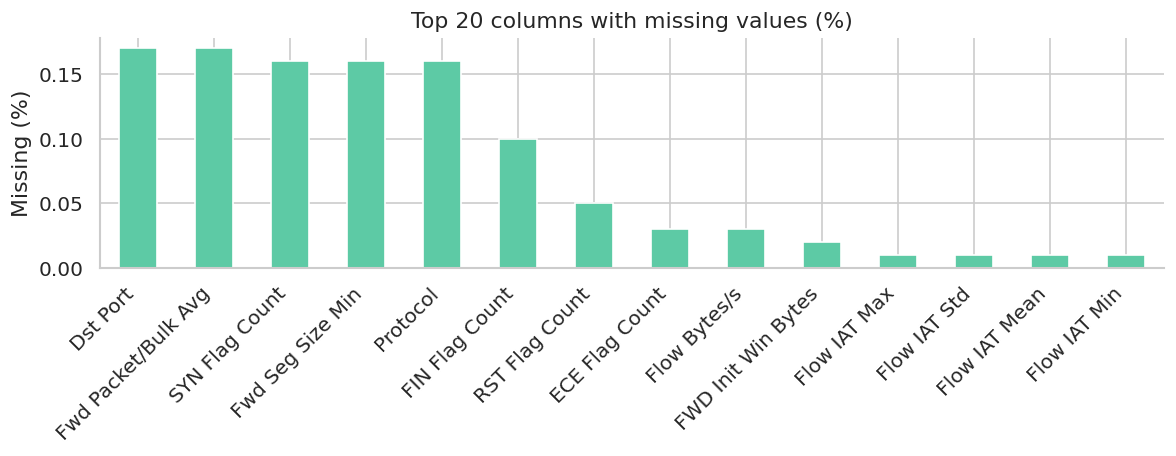


Duplicate rows : 1,445  (0.08%)


In [10]:
if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df.to_string())
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df["pct"].head(20).plot(kind="bar", ax=ax, color="#5DCAA5")
    ax.set_title("Top 20 columns with missing values (%)")
    ax.set_ylabel("Missing (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("eda_01_missing_values.png")
    plt.show()
dupes = df.duplicated().sum()
print(f"\nDuplicate rows : {dupes:,}  ({dupes/len(df)*100:.2f}%)")

In [11]:
inf_count = np.isinf(df[feature_cols].select_dtypes("number")).sum()
inf_cols = inf_count[inf_count > 0]
if not inf_cols.empty:
    print("\nColumns with Inf values:")
    print(inf_cols.to_string())
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print("  → Replaced Inf with NaN.")


Columns with Inf values:
Flow Bytes/s      155
Flow Packets/s    716
  → Replaced Inf with NaN.



Label Distribution
                                         count   pct%
Label                                                
BENIGN                                 1180520  66.49
PortScan                                134270   7.56
DoS Hulk                                113817   6.41
DDoS                                     80303   4.52
benign                                   38947   2.19
Benign                                   19737   1.11
BENIGNN                                   7828   0.44
BENING                                    3999   0.23
BENIG                                     3959   0.22
ENIGN                                     3945   0.22
BEENIGN                                   3937   0.22
BBENIGN                                   3936   0.22
BENIN                                     3928   0.22
BEINGN                                    3919   0.22
BEIGN                                     3912   0.22
BENIIGN                                   3894   0.22
BNEIGN  

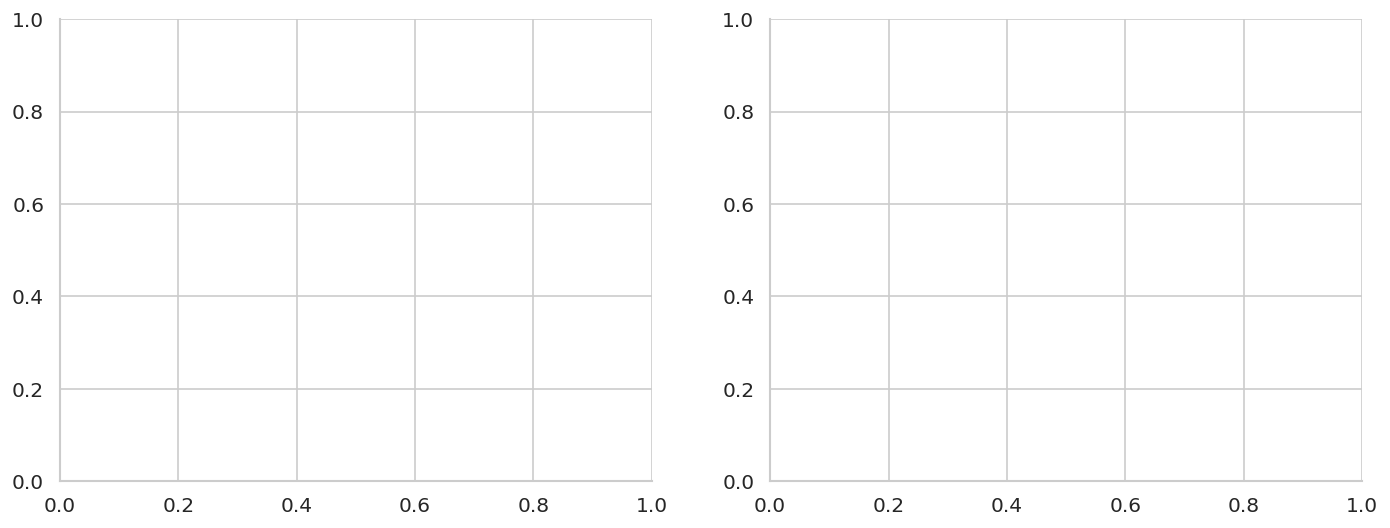

In [13]:
print("\n" + "=" * 60)
print("Label Distribution")
print("=" * 60)

label_counts = df[LABEL_COL].value_counts()
label_pct    = (label_counts / len(df) * 100).round(2)
print(pd.concat([label_counts.rename("count"), label_pct.rename("pct%")], axis=1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [14]:
# Pie Chart
label_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted", len(label_counts)))
axes[0].set_title("Class counts (log scale)")
axes[0].set_yscale("log")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

In [15]:
# Bar Chart
label_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted", len(label_counts)))
axes[0].set_title("Class counts (log scale)")
axes[0].set_yscale("log")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

In [16]:
wedge_props = {"linewidth": 0.8, "edgecolor": "white"}
axes[1].pie(label_counts, labels=label_counts.index, autopct="%1.1f%%",
            startangle=140, wedgeprops=wedge_props,
            colors=sns.color_palette("muted", len(label_counts)))
axes[1].set_title("Class proportion")
plt.suptitle("Label Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_02_label_distribution.png", bbox_inches="tight")
plt.show()

<Figure size 768x576 with 0 Axes>

In [17]:
majority = label_counts.iloc[0]
minority = label_counts.iloc[-1]
print(f"\nImbalance ratio (majority/minority): {majority/minority:.1f}x")


Imbalance ratio (majority/minority): 1180520.0x



Feature Distributions (histograms)
Numeric features: 70


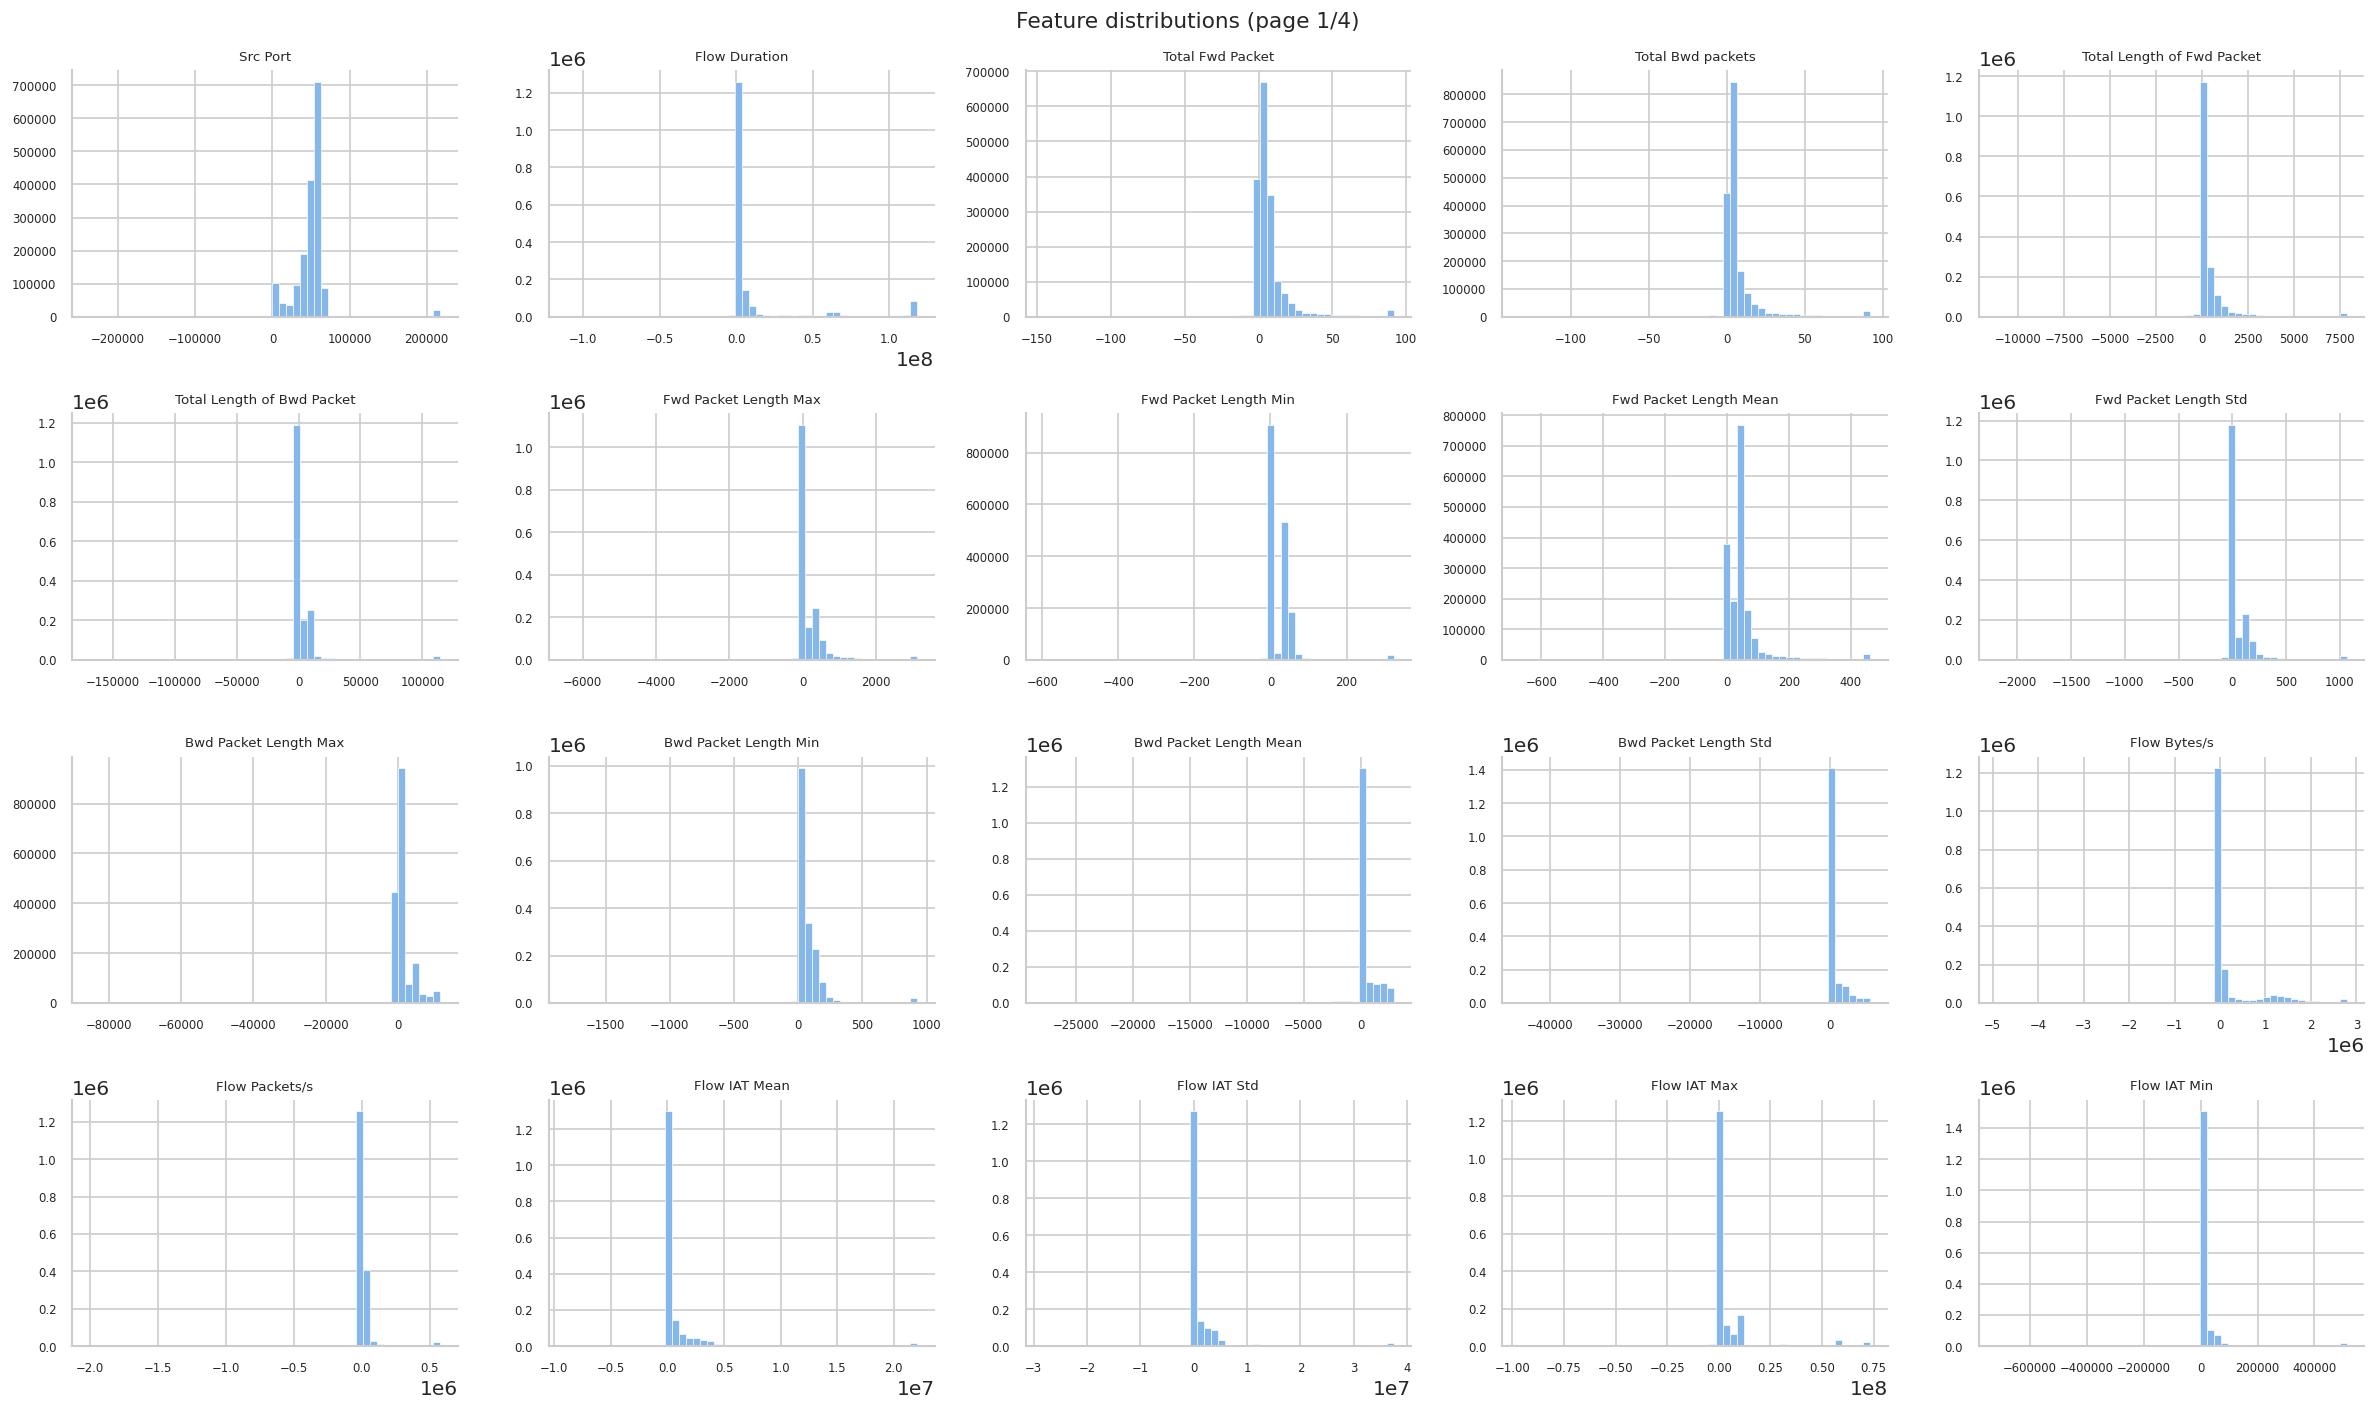

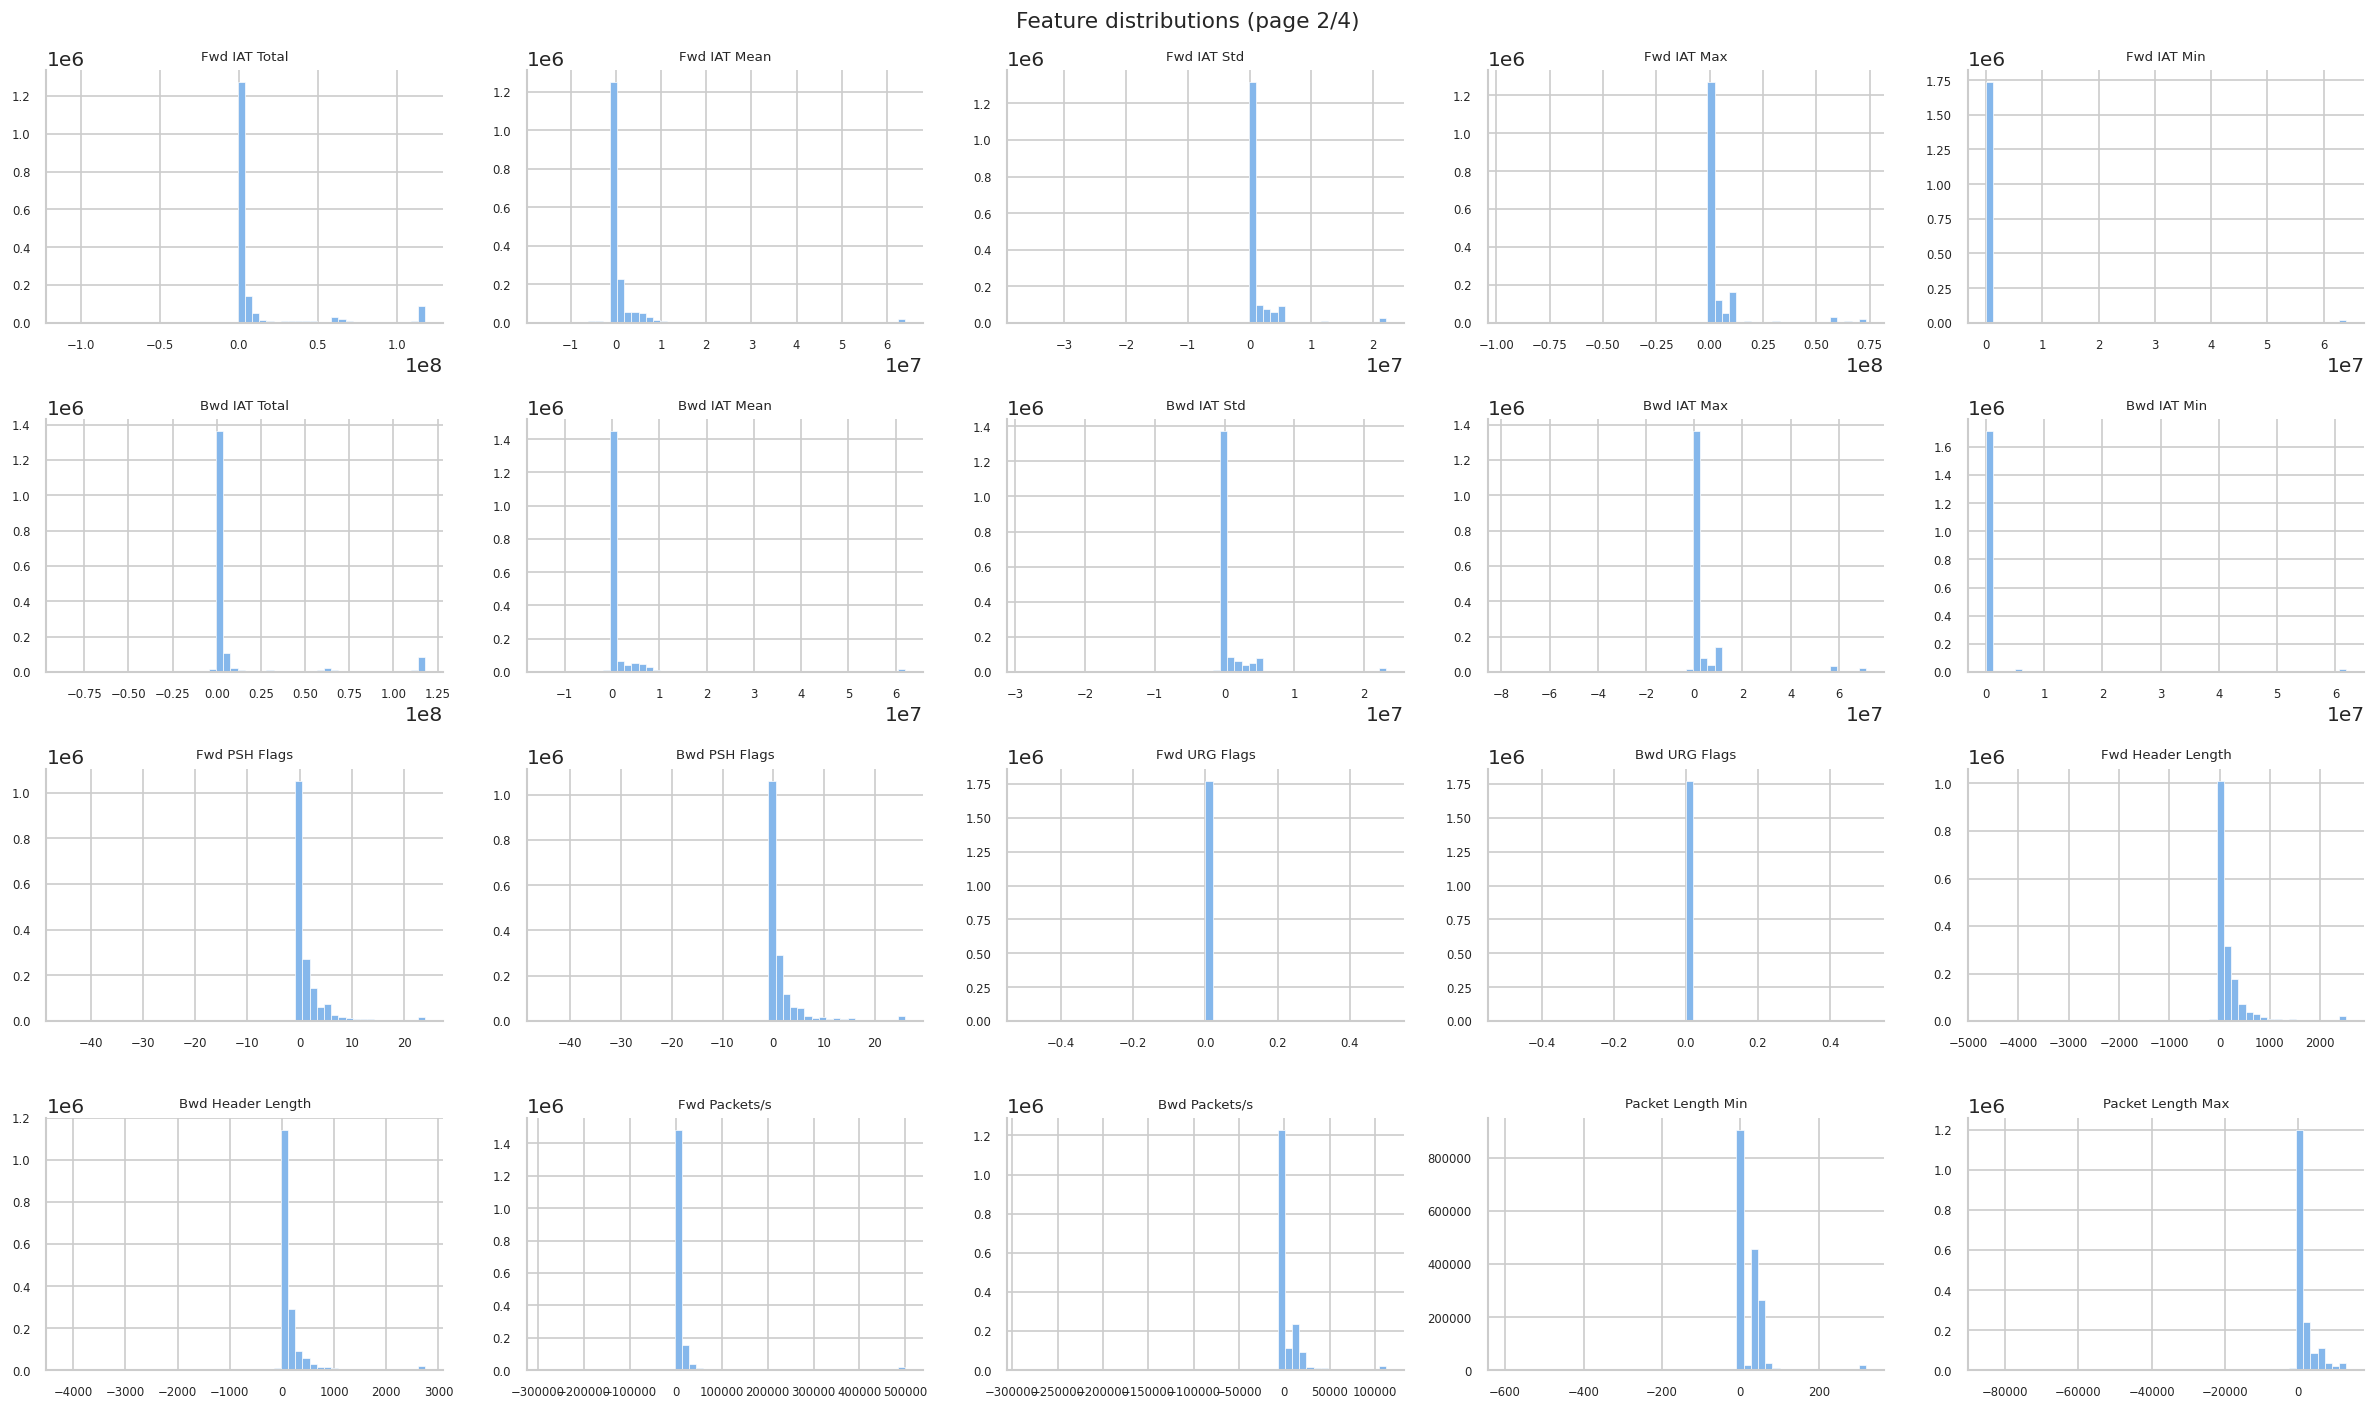

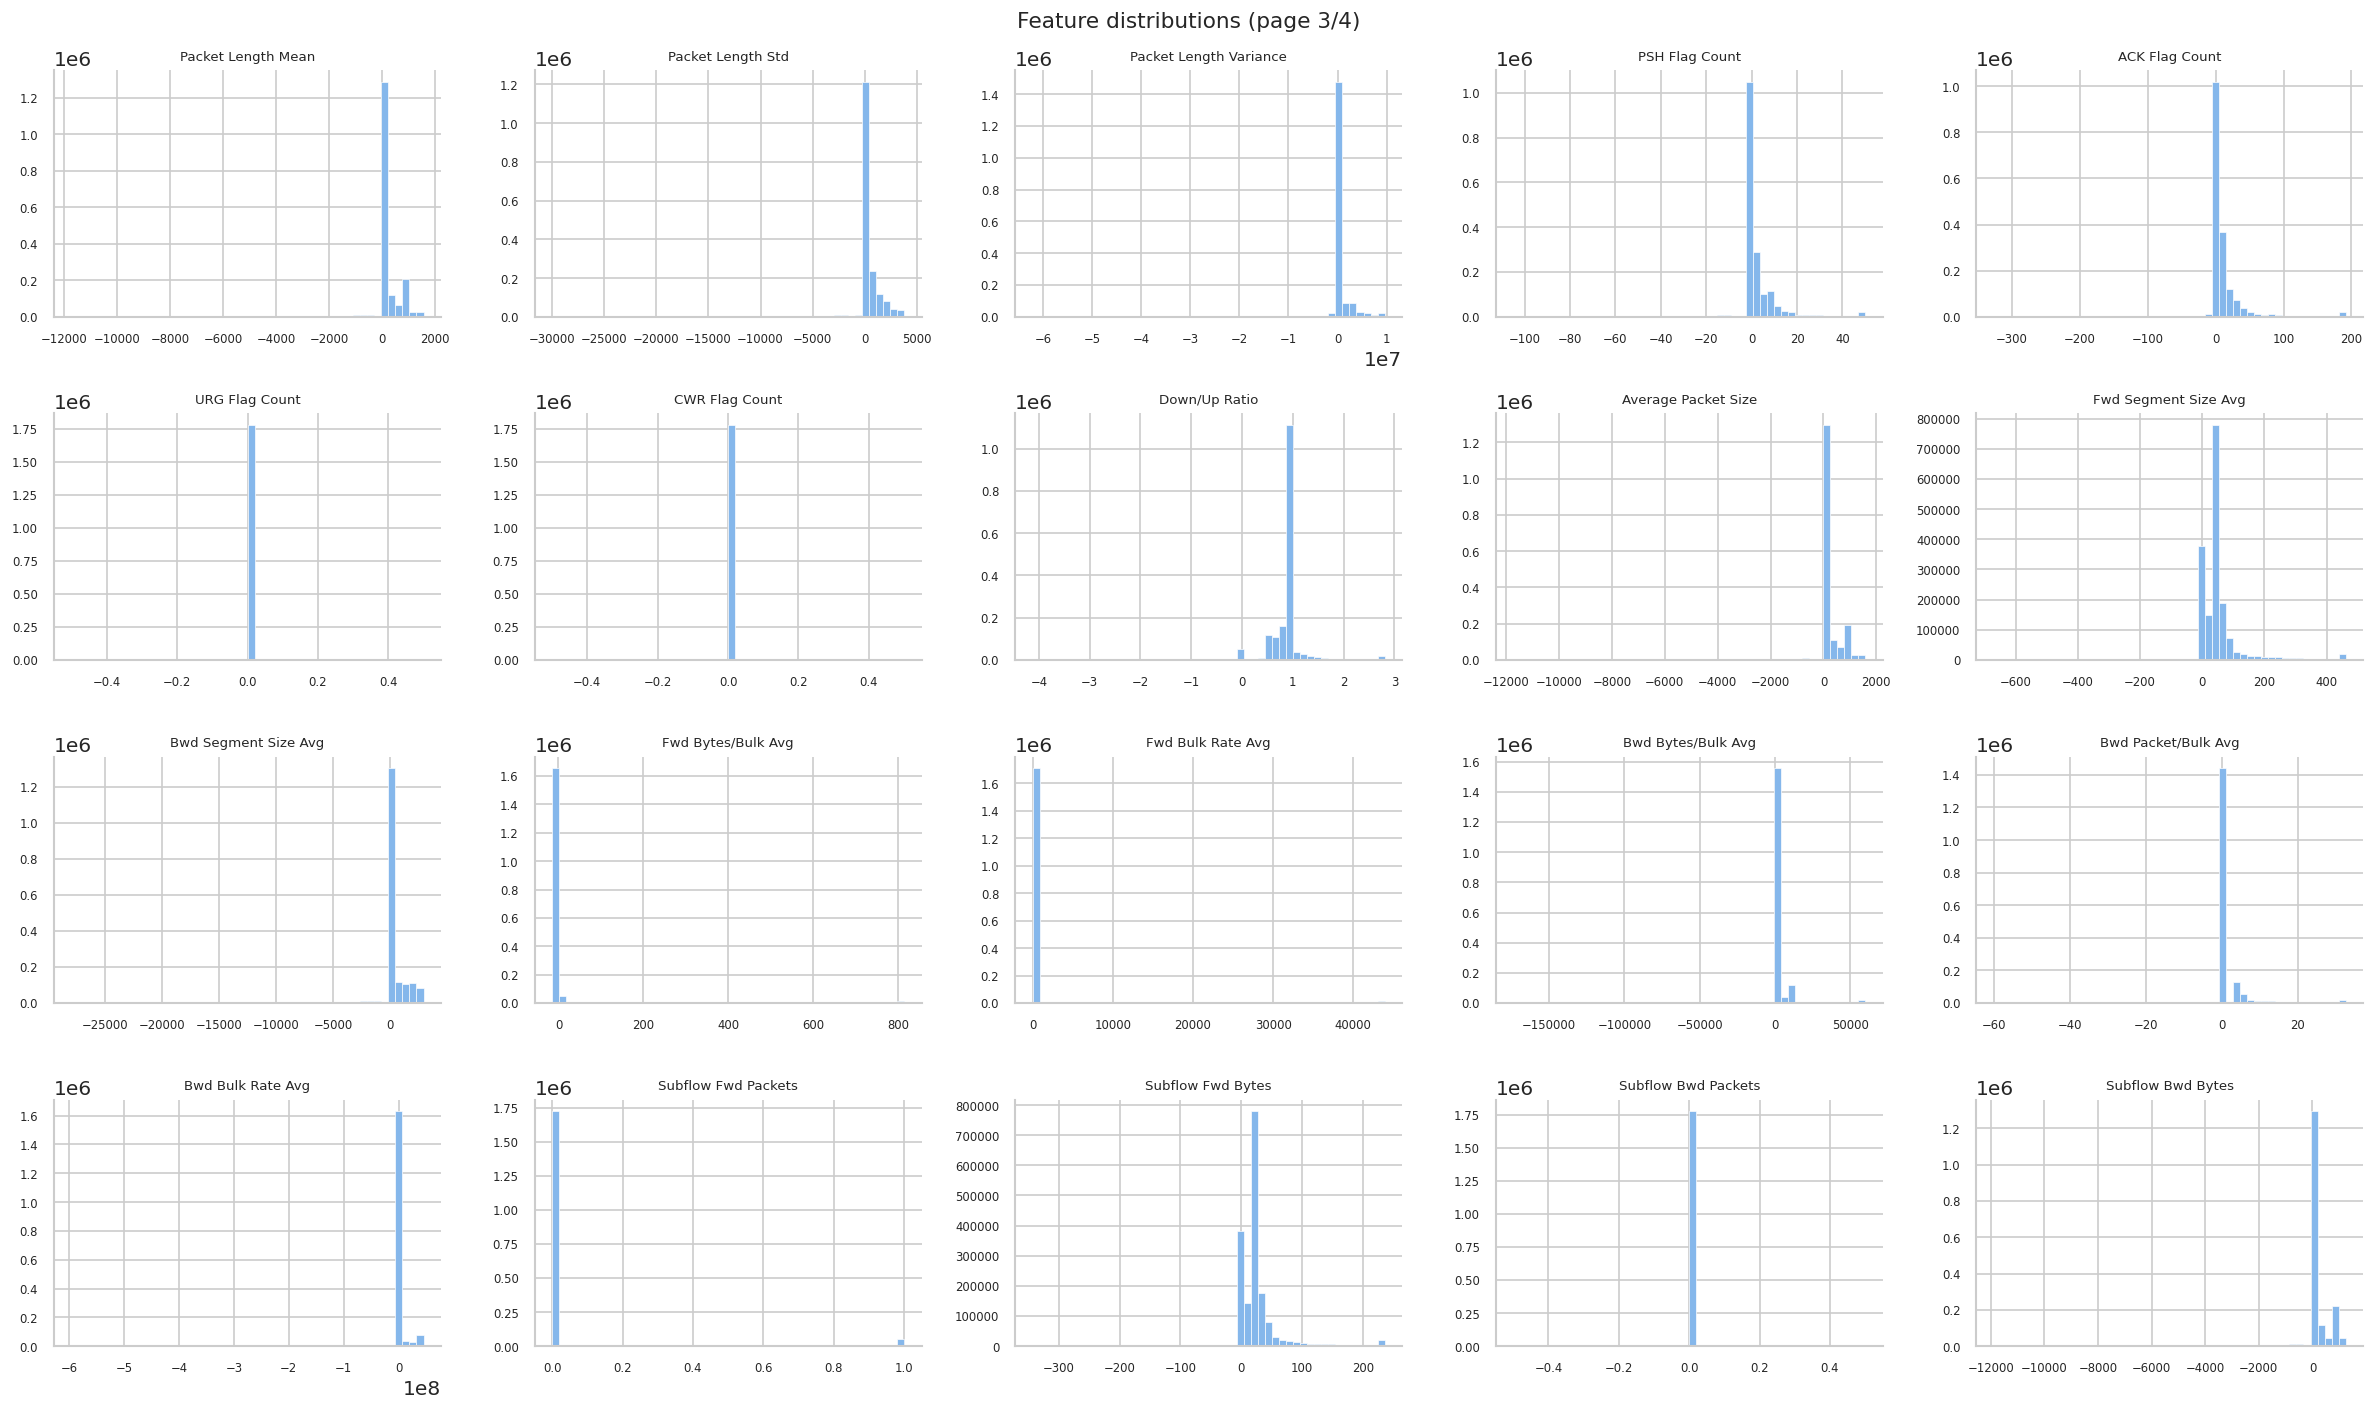

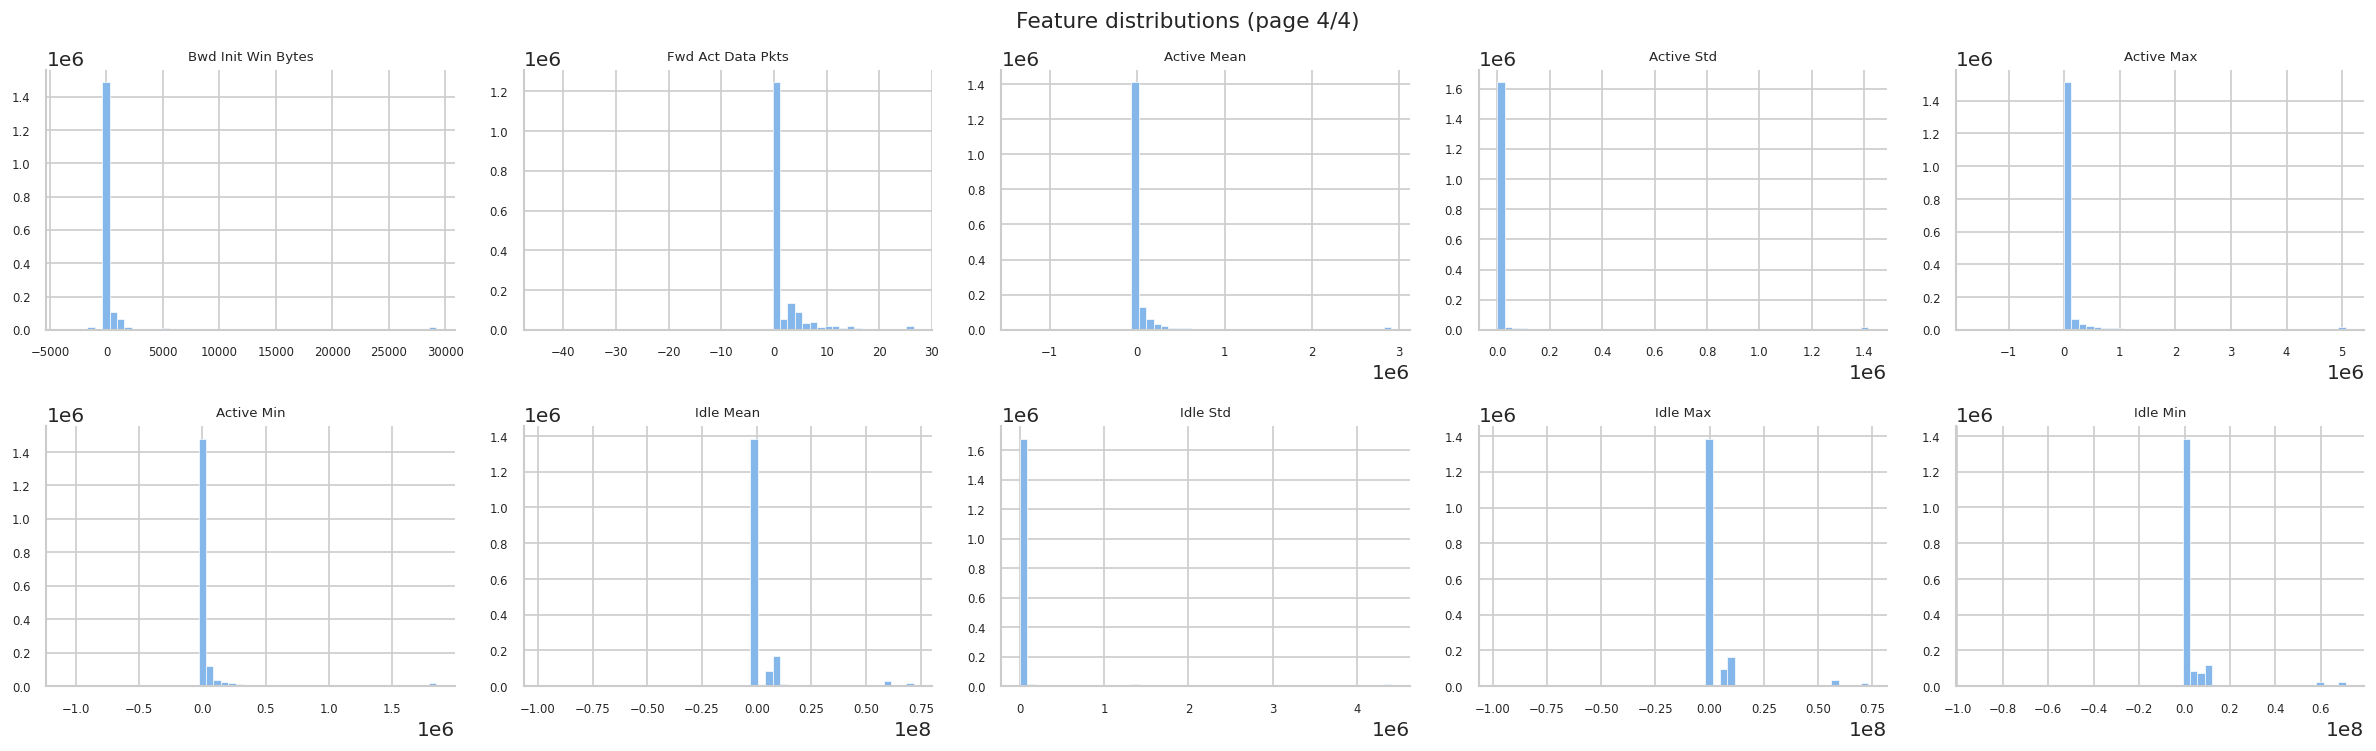

In [18]:
print("\n" + "=" * 60)
print("Feature Distributions (histograms)")
print("=" * 60)
numeric_cols = df[feature_cols].select_dtypes(include="number").columns.tolist()
print(f"Numeric features: {len(numeric_cols)}")

n_cols, n_rows = 5, 4
per_page = n_cols * n_rows
pages = (len(numeric_cols) + per_page - 1) // per_page

for page in range(pages):
    cols_subset = numeric_cols[page * per_page: (page + 1) * per_page]
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
    axes = axes.flatten()
    for i, col in enumerate(cols_subset):
        data = df[col].dropna()
        axes[i].hist(data.clip(upper=np.percentile(data, 99)), bins=50,
                     color="#85B7EB", edgecolor="white", linewidth=0.4)
        axes[i].set_title(col, fontsize=8)
        axes[i].tick_params(labelsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"Feature distributions (page {page+1}/{pages})", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"eda_03_distributions_p{page+1}.png")
    plt.show()


Skewness & Kurtosis

Top 10 most skewed features:
                               skewness      kurtosis
Bwd URG Flags               1332.454502  1.775435e+06
Total Length of Fwd Packet   932.553256  1.066077e+06
Fwd Bytes/Bulk Avg           433.310556  2.681328e+05
Bwd Bytes/Bulk Avg           405.323516  1.823958e+05
Bwd Packet/Bulk Avg          393.203280  1.800136e+05
CWR Flag Count               337.150733  2.227177e+05
Fwd PSH Flags                254.128212  1.223755e+05
Total Length of Bwd Packet   203.735354  4.272491e+04
Fwd Header Length            202.151841  4.236383e+04
ACK Flag Count               200.798953  4.168456e+04


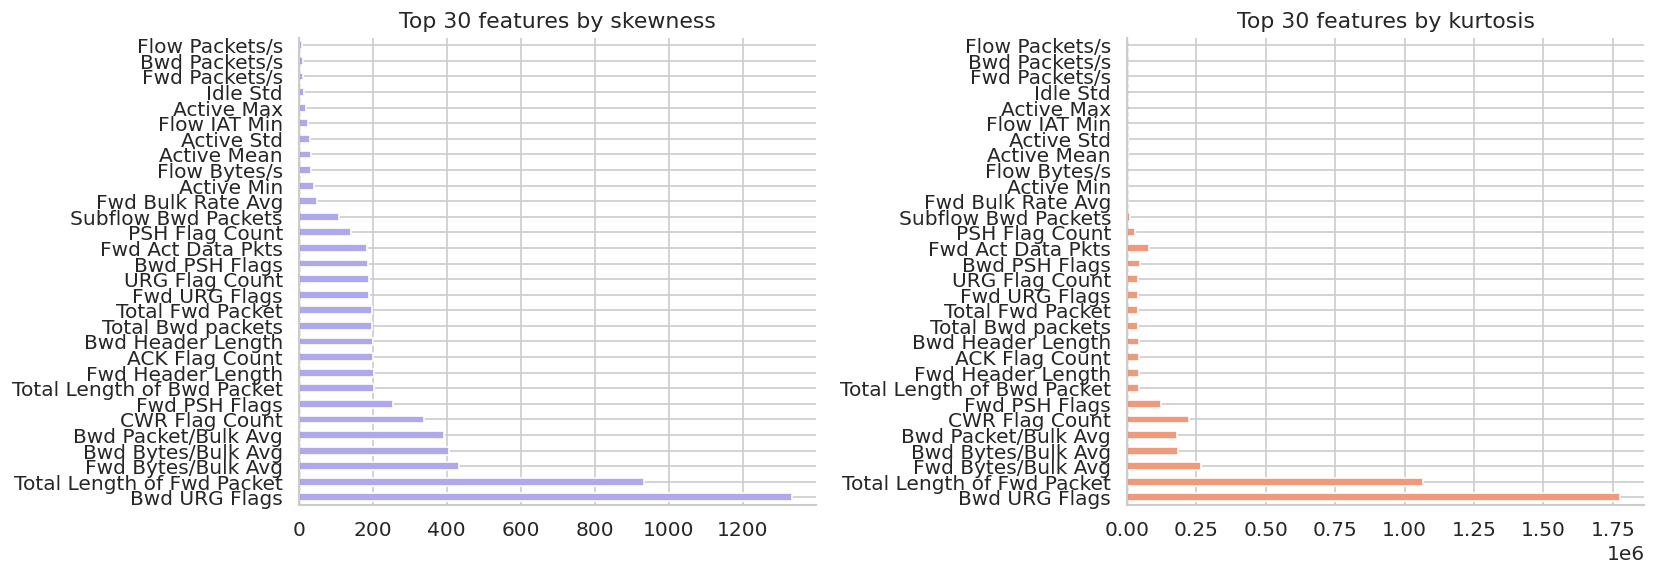

In [21]:
print("\n" + "=" * 60)
print("Skewness & Kurtosis")
print("=" * 60)

skew_kurt = pd.DataFrame({
    "skewness": df[numeric_cols].skew(),
    "kurtosis": df[numeric_cols].kurt()
}).sort_values("skewness", ascending=False)

print("\nTop 10 most skewed features:")
print(skew_kurt.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
skew_kurt["skewness"].head(30).plot(kind="barh", ax=axes[0], color="#AFA9EC")
axes[0].set_title("Top 30 features by skewness")
axes[0].axvline(0, color="gray", lw=0.8, ls="--")

skew_kurt["kurtosis"].head(30).plot(kind="barh", ax=axes[1], color="#F0997B")
axes[1].set_title("Top 30 features by kurtosis")
axes[1].axvline(0, color="gray", lw=0.8, ls="--")

plt.tight_layout()
plt.savefig("eda_04_skew_kurtosis.png")
plt.show()



Correlation Heatmap

Feature pairs with |correlation| > 0.90: 20
  URG Flag Count  ↔  Fwd URG Flags   r=1.0
  Total Length of Bwd Packet  ↔  Total Bwd packets   r=0.972
  Bwd Header Length  ↔  Total Bwd packets   r=0.964
  ACK Flag Count  ↔  Fwd Header Length   r=0.961
  Total Bwd packets  ↔  Total Fwd Packet   r=0.949
  Fwd Header Length  ↔  Total Bwd packets   r=0.949
  ACK Flag Count  ↔  Bwd Header Length   r=0.941
  ACK Flag Count  ↔  Total Fwd Packet   r=0.936
  ACK Flag Count  ↔  Total Bwd packets   r=0.936
  Bwd Header Length  ↔  Total Fwd Packet   r=0.932
  Bwd Header Length  ↔  Total Length of Bwd Packet   r=0.931
  Bwd Header Length  ↔  Fwd Header Length   r=0.931
  Total Length of Bwd Packet  ↔  Total Fwd Packet   r=0.926
  Fwd Header Length  ↔  Total Length of Bwd Packet   r=0.926
  Fwd Header Length  ↔  Total Fwd Packet   r=0.923


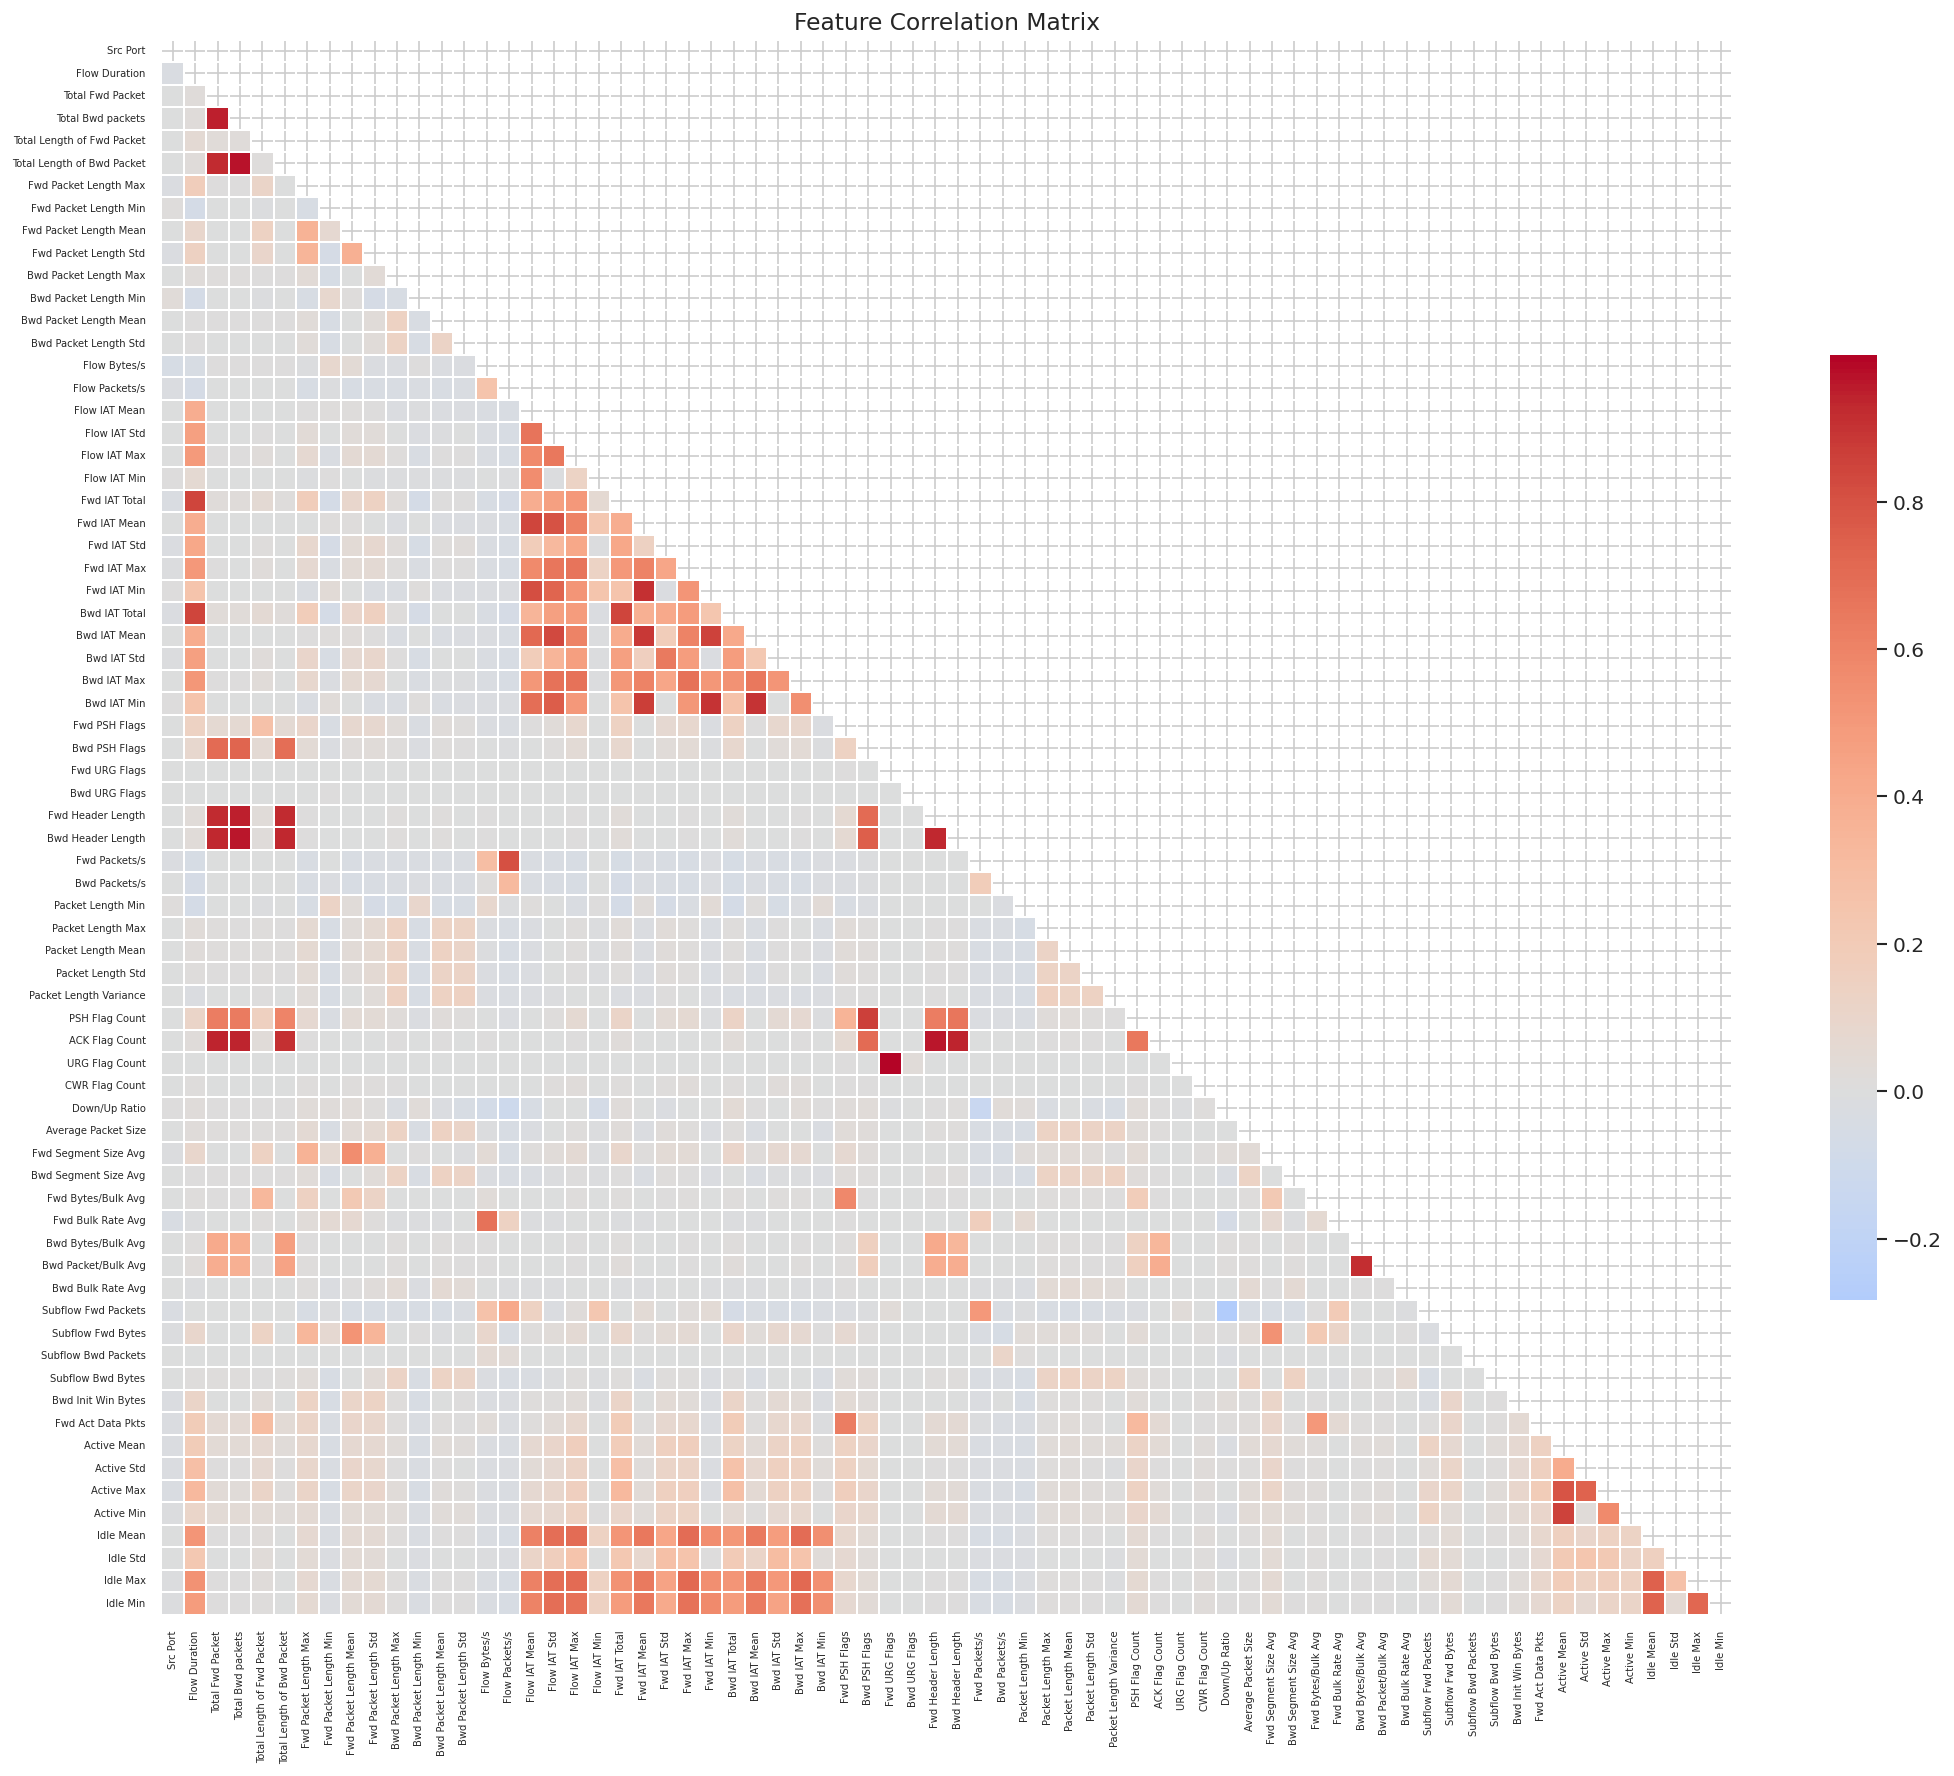

In [23]:
print("\n" + "=" * 60)
print("Correlation Heatmap")
print("=" * 60)

corr_matrix = df[numeric_cols].corr()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, round(upper.loc[row, col], 3))
             for col in upper.columns
             for row in upper.index
             if abs(upper.loc[row, col]) > 0.90]
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\nFeature pairs with |correlation| > 0.90: {len(high_corr)}")
for pair in high_corr[:15]:
    print(f"  {pair[0]}  ↔  {pair[1]}   r={pair[2]}")

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.2, ax=ax, cbar_kws={"shrink": 0.6},
            xticklabels=True, yticklabels=True)
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("eda_05_correlation_heatmap.png", bbox_inches="tight")
plt.show()


Feature vs Label (Box Plots)


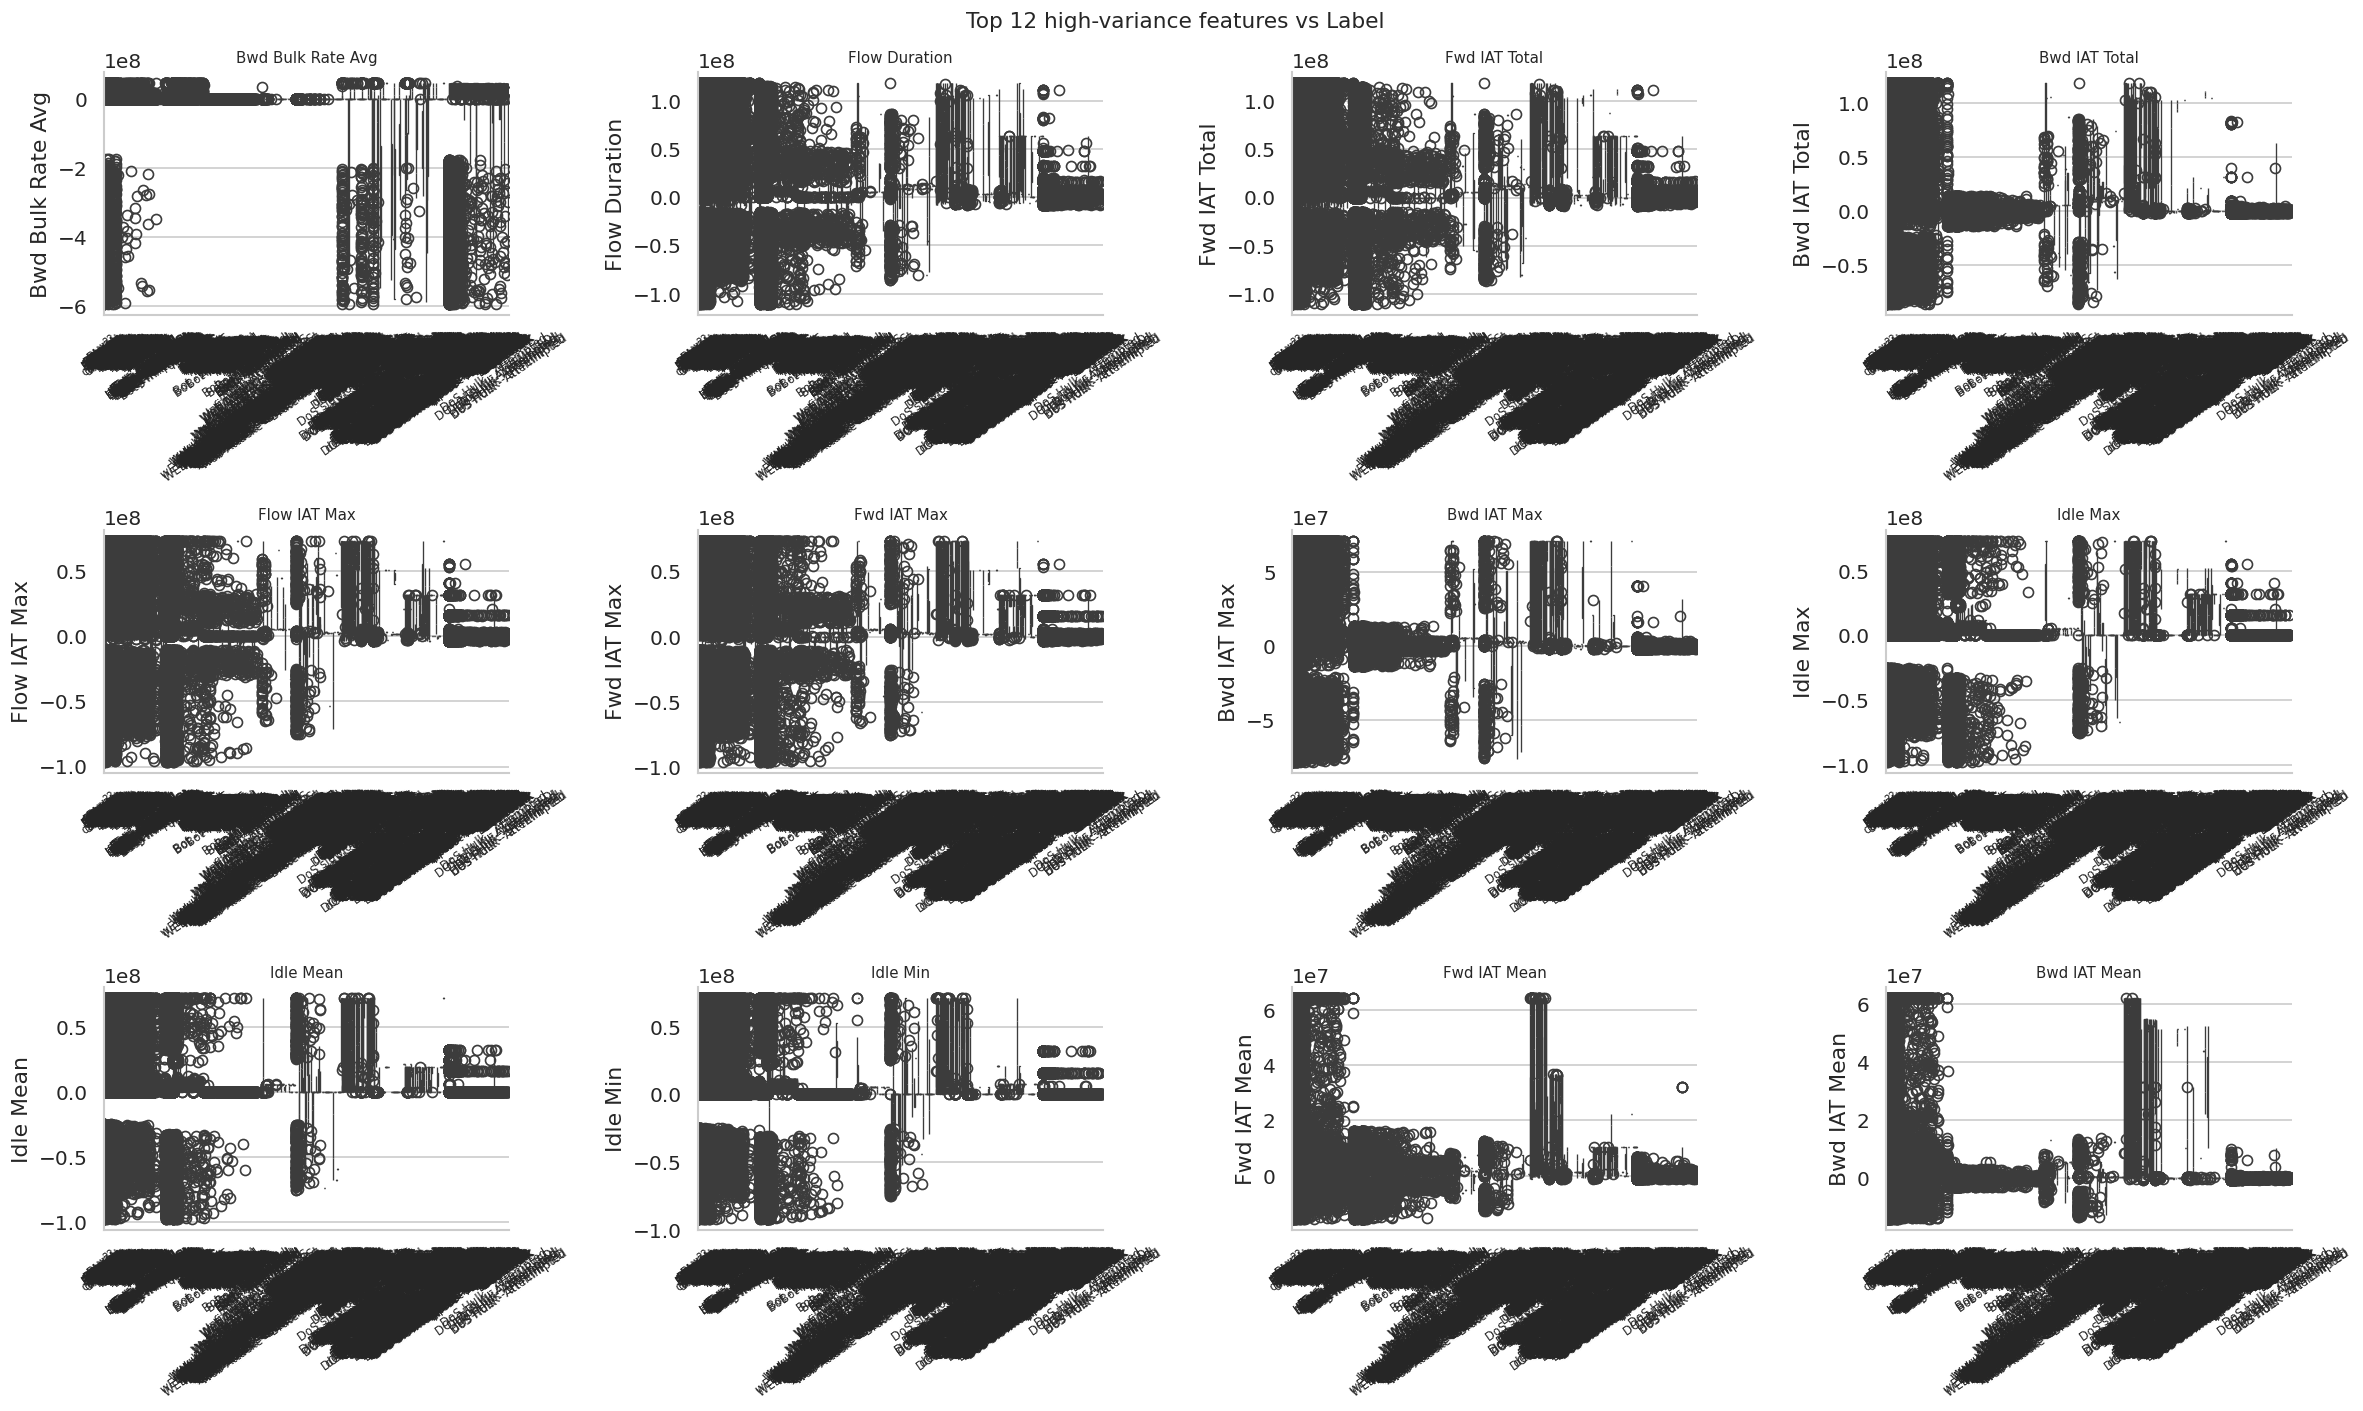

In [24]:
print("\n" + "=" * 60)
print("Feature vs Label (Box Plots)")
print("=" * 60)

top_var = df[numeric_cols].var().sort_values(ascending=False).head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(top_var):
    plot_data = df[[col, LABEL_COL]].copy()
    plot_data[col] = plot_data[col].clip(
        upper=np.percentile(plot_data[col].dropna(), 99)
    )
    sns.boxplot(data=plot_data, x=LABEL_COL, y=col, ax=axes[i],
                palette="muted", linewidth=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", rotation=35, labelsize=7)
    axes[i].set_xlabel("")
plt.suptitle("Top 12 high-variance features vs Label", fontsize=13)
plt.tight_layout()
plt.savefig("eda_06_boxplots.png", bbox_inches="tight")
plt.show()

In [25]:
print("\n" + "=" * 60)
print("Zero / Near-Zero Variance Features")
print("=" * 60)

zero_var = [c for c in numeric_cols if df[c].nunique() <= 1]
print(f"Zero-variance columns ({len(zero_var)}): {zero_var}")

nzv = [c for c in numeric_cols
       if df[c].value_counts(normalize=True).iloc[0] > 0.95
       and c not in zero_var]
print(f"\nNear-zero-variance columns ({len(nzv)}):")
for c in nzv:
    top_val = df[c].value_counts(normalize=True).iloc[0]
    print(f"  {c}  → {top_val*100:.1f}% same value")


Zero / Near-Zero Variance Features
Zero-variance columns (0): []

Near-zero-variance columns (6):
  Fwd URG Flags  → 100.0% same value
  Bwd URG Flags  → 100.0% same value
  URG Flag Count  → 100.0% same value
  CWR Flag Count  → 100.0% same value
  Subflow Fwd Packets  → 97.0% same value
  Subflow Bwd Packets  → 100.0% same value



Outlier Summary (IQR)

Top 15 columns by outlier count:
Idle Min             26.26
Idle Mean            26.25
Idle Max             26.23
Active Mean          25.93
Active Min           25.93
Active Max           25.93
Bwd IAT Std          24.61
Bwd IAT Mean         23.79
Bwd IAT Total        23.78
Bwd IAT Max          23.41
Fwd PSH Flags        23.18
Fwd IAT Std          23.16
Flow Bytes/s         21.48
PSH Flag Count       20.90
Subflow Bwd Bytes    20.88


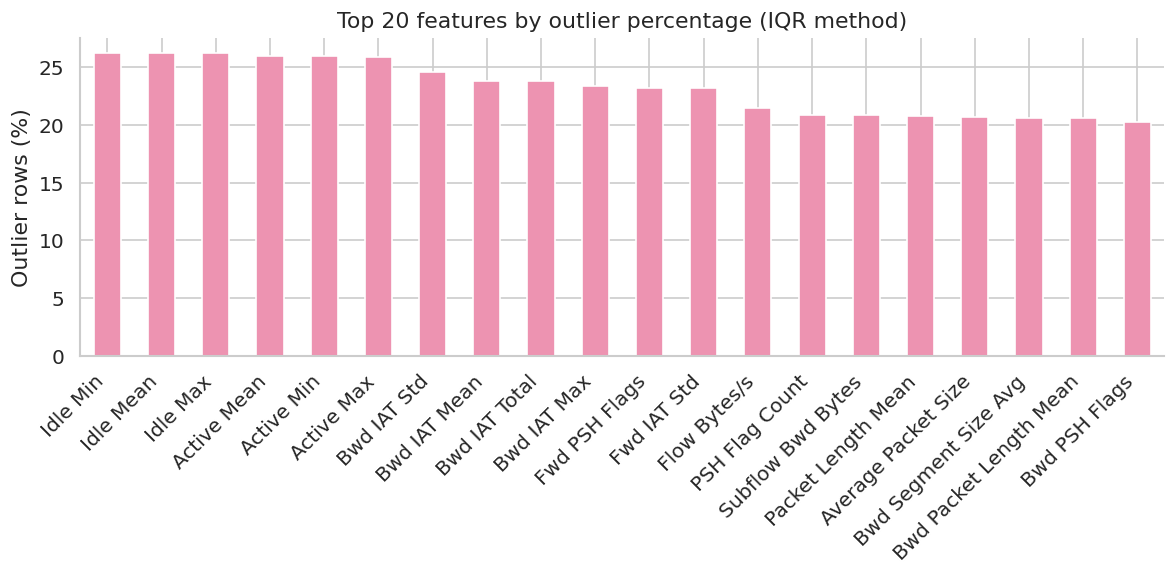

In [26]:
print("\n" + "=" * 60)
print("Outlier Summary (IQR)")
print("=" * 60)

outlier_summary = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    outlier_summary[col] = n_out

outlier_df = pd.Series(outlier_summary).sort_values(ascending=False)
print("\nTop 15 columns by outlier count:")
print((outlier_df.head(15) / len(df) * 100).round(2).rename("outlier_pct%").to_string())

fig, ax = plt.subplots(figsize=(10, 5))
(outlier_df.head(20) / len(df) * 100).plot(kind="bar", ax=ax, color="#ED93B1")
ax.set_title("Top 20 features by outlier percentage (IQR method)")
ax.set_ylabel("Outlier rows (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda_07_outliers.png")
plt.show()



Feature Importance (Random Forest proxy)

Top 20 most important features:
                   feature  importance
    Packet Length Variance    0.081376
     Bwd Packet Length Std    0.057730
         Packet Length Std    0.047453
    Bwd Packet Length Mean    0.040962
     Bwd Packet Length Max    0.037313
     Fwd Packet Length Max    0.037136
      Fwd Segment Size Avg    0.036087
             Flow Duration    0.033943
       Average Packet Size    0.033631
             Bwd Packets/s    0.032693
        Packet Length Mean    0.031851
Total Length of Bwd Packet    0.031220
    Fwd Packet Length Mean    0.030047
      Bwd Segment Size Avg    0.028790
         Subflow Fwd Bytes    0.026497
         Packet Length Max    0.024863
             Fwd IAT Total    0.023574
              Flow IAT Max    0.022903
              Fwd IAT Mean    0.022474
         Fwd Header Length    0.021757


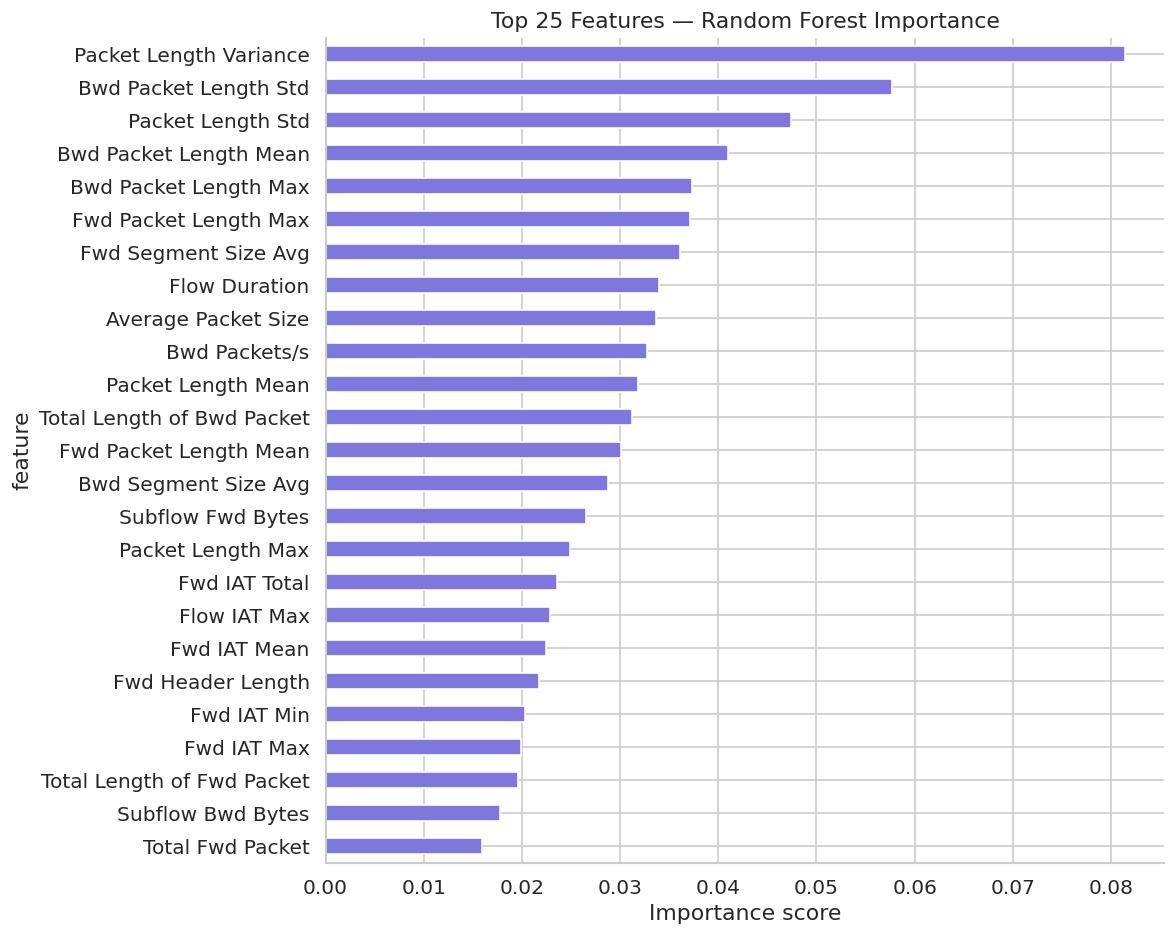

In [28]:
print("\n" + "=" * 60)
print("Feature Importance (Random Forest proxy)")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

sample = df[numeric_cols + [LABEL_COL]].dropna(subset=[LABEL_COL])
if len(sample) > 100_000:
    sample = sample.sample(100_000, random_state=42)

X = sample[numeric_cols]
y = LabelEncoder().fit_transform(sample[LABEL_COL].astype(str))

imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X)

rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             n_jobs=-1, random_state=42)
rf.fit(X_imp, y)

importance_df = pd.DataFrame({
    "feature":    numeric_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 most important features:")
print(importance_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
importance_df.head(25).set_index("feature")["importance"].plot(
    kind="barh", ax=ax, color="#7F77DD")
ax.invert_yaxis()
ax.set_title("Top 25 Features — Random Forest Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("eda_08_feature_importance.png")
plt.show()

In [30]:
print("\n" + "=" * 60)
print("EDA SUMMARY REPORT")
print("=" * 60)
print(f"  Total rows              : {len(df):,}")
print(f"  Total features          : {len(feature_cols)}")
print(f"  Numeric features        : {len(numeric_cols)}")
print(f"  Missing value columns   : {len(missing_df)}")
print(f"  Duplicate rows          : {dupes:,}")
print(f"  Inf-value columns       : {len(inf_cols)}")
print(f"  Zero-variance features  : {len(zero_var)}")
print(f"  Near-zero-var features  : {len(nzv)}")
print(f"  High-corr pairs (>0.9)  : {len(high_corr)}")
print(f"  Unique labels           : {df[LABEL_COL].nunique()}")
print(f"  Class imbalance ratio   : {majority/minority:.1f}x")


EDA SUMMARY REPORT
  Total rows              : 1,775,435
  Total features          : 79
  Numeric features        : 70
  Missing value columns   : 14
  Duplicate rows          : 1,445
  Inf-value columns       : 2
  Zero-variance features  : 0
  Near-zero-var features  : 6
  High-corr pairs (>0.9)  : 20
  Unique labels           : 1588
  Class imbalance ratio   : 1180520.0x
